# XGBoost Improved

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from xgboost import XGBRegressor

### Load Data

In [2]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')
test_ids = test_df['id'].copy()

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
train_df.head()

Train shape: (630000, 13)
Test shape: (270000, 12)


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


### Preprocess

In [3]:
categorical_cols = ['gender', 'course', 'internet_access', 'sleep_quality',
                    'study_method', 'facility_rating', 'exam_difficulty']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))
    label_encoders[col] = le

feature_cols = [c for c in train_df.columns if c not in ['id', 'exam_score']]

X = train_df[feature_cols]
y = train_df['exam_score']
X_submission = test_df[feature_cols]

print(f'Features: {feature_cols}')

Features: ['age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']


### K-Fold Cross-Validation

### Train (K-Fold Loop + Final Model)

In [4]:
# Kfold initiaiton
N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# containers and training sample variable creation
fold_metrics = []
preds = np.zeros(len(X))
best_iterations = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f'\nFold {fold + 1}/{N_SPLITS}')

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # early stopping
    fold_model = XGBRegressor(
        n_estimators=1000,      
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        early_stopping_rounds=100,
        verbosity=1
    )

    fold_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=200
    )

    val_pred = fold_model.predict(X_val)
    preds[val_idx] = val_pred

    # record best tree count
    best_iterations.append(fold_model.best_iteration)

    # metrics
    fold_mae  = metrics.mean_absolute_error(y_val, val_pred)
    fold_rmse = np.sqrt(metrics.mean_squared_error(y_val, val_pred))
    fold_r2   = metrics.r2_score(y_val, val_pred)
    fold_metrics.append({'fold': fold + 1, 'MAE': fold_mae, 'RMSE': fold_rmse, 'R2': fold_r2})
    print(f'Fold {fold + 1} — MAE: {fold_mae:.4f}, RMSE: {fold_rmse:.4f}, R2: {fold_r2:.4f}')

# final tree count
mean_best_iter = int(np.mean(best_iterations)) + 1
print(f'\nBest iterations per fold: {best_iterations}')
print(f'Mean best iteration: {mean_best_iter}')

# train final model on all training data
model = XGBRegressor(
    n_estimators=mean_best_iter,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=1
)
model.fit(X, y, verbose=200)
print(f'\nFinal model ({mean_best_iter} estimators)')


Fold 1/5
[0]	validation_0-rmse:18.20604
[200]	validation_0-rmse:8.78579
[400]	validation_0-rmse:8.76250
[600]	validation_0-rmse:8.75017
[800]	validation_0-rmse:8.74406
[999]	validation_0-rmse:8.74094
Fold 1 — MAE: 6.9664, RMSE: 8.7407, R2: 0.7852

Fold 2/5
[0]	validation_0-rmse:18.24902
[200]	validation_0-rmse:8.79952
[400]	validation_0-rmse:8.77540
[600]	validation_0-rmse:8.76299
[800]	validation_0-rmse:8.75625
[999]	validation_0-rmse:8.75208
Fold 2 — MAE: 6.9864, RMSE: 8.7521, R2: 0.7856

Fold 3/5
[0]	validation_0-rmse:18.25429
[200]	validation_0-rmse:8.78893
[400]	validation_0-rmse:8.76376
[600]	validation_0-rmse:8.75149
[800]	validation_0-rmse:8.74475
[999]	validation_0-rmse:8.74178
Fold 3 — MAE: 6.9797, RMSE: 8.7418, R2: 0.7863

Fold 4/5
[0]	validation_0-rmse:18.31338
[200]	validation_0-rmse:8.80645
[400]	validation_0-rmse:8.78336
[600]	validation_0-rmse:8.77232
[800]	validation_0-rmse:8.76589
[999]	validation_0-rmse:8.76331
Fold 4 — MAE: 6.9787, RMSE: 8.7632, R2: 0.7866

Fold 5/

In [ ]:
# feature analysis
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.to_string(index=False))

         feature  importance
     study_hours    0.517177
   sleep_quality    0.162569
 facility_rating    0.098754
    study_method    0.096994
class_attendance    0.087926
     sleep_hours    0.025424
             age    0.002448
          course    0.002314
          gender    0.002277
 exam_difficulty    0.002109
 internet_access    0.002007


### Evaluate

Per-Fold Metrics:
 fold      MAE     RMSE       R2
    1 6.966392 8.740717 0.785180
    2 6.986372 8.752078 0.785636
    3 6.979748 8.741780 0.786261
    4 6.978656 8.763242 0.786565
    5 6.991356 8.775816 0.785418

OOF Aggregate Metrics (all 5 folds):
  MAE:  6.98050495350199
  MSE:  76.64541366916681
  RMSE: 8.754736641908014
  R2:   0.7858156899209875


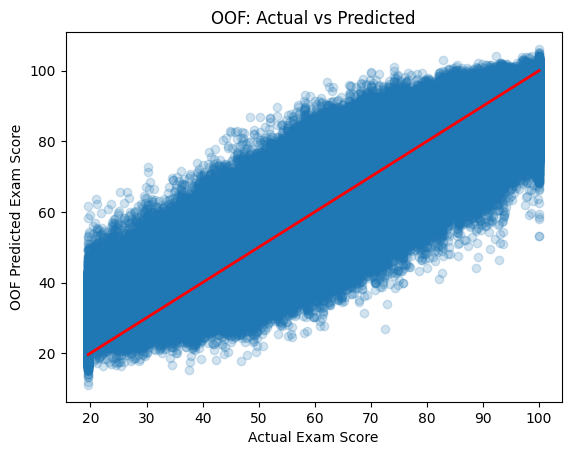

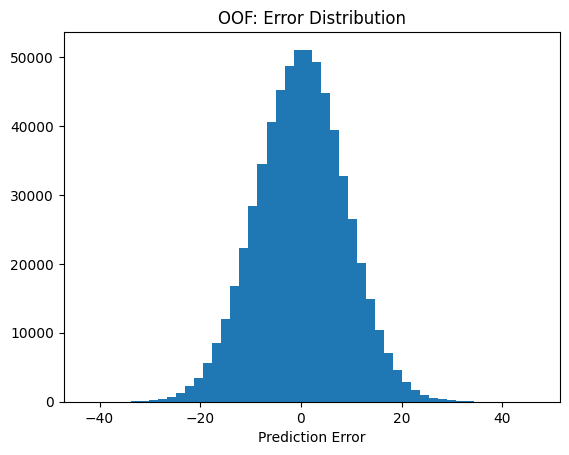

Metrics saved to ../metrics/xgboost_improved_metrics.csv


,MAE,MSE,RMSE,R2
0,6.980505,76.645414,8.754737,0.785816


In [6]:
# metrics table
fold_metrics_df = pd.DataFrame(fold_metrics)
print('Per-Fold Metrics:')
print(fold_metrics_df.to_string(index=False))

# out of fold metrics
oof_mae  = metrics.mean_absolute_error(y,preds)
oof_mse  = metrics.mean_squared_error(y,preds)
oof_rmse = np.sqrt(oof_mse)
oof_r2   = metrics.r2_score(y,preds)

print(f'\nOOF Aggregate Metrics (all {N_SPLITS} folds):')
print(f'  MAE:  {oof_mae}')
print(f'  MSE:  {oof_mse:}')
print(f'  RMSE: {oof_rmse:}')
print(f'  R2:   {oof_r2:}')

# actual vs OOF 
plt.scatter(y,preds, alpha=0.2)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r', lw=2)
plt.xlabel('Actual Exam Score')
plt.ylabel('OOF Predicted Exam Score')
plt.title('OOF: Actual vs Predicted')
plt.show()

# error distribution
plt.hist(y - preds, bins=50)
plt.xlabel('Prediction Error')
plt.title('OOF: Error Distribution')
plt.show()

pd.set_option('float_format', '{:f}'.format)
res_metrics = pd.DataFrame({
    'MAE':  [oof_mae],
    'MSE':  [oof_mse],
    'RMSE': [oof_rmse],
    'R2':   [oof_r2],
})
res_metrics.to_csv('../metrics/xgboost_improved_metrics.csv', index=False)
print('Metrics saved to ../metrics/xgboost_improved_metrics.csv')
res_metrics

### Generate Submission

In [7]:
y_submission_pred = model.predict(X_submission)
submission = pd.DataFrame({'id': test_ids, 'exam_score': y_submission_pred})
submission.to_csv('../submission/xgboost_improved_submission.csv', index=False)
print('Submission saved to ../submission/xgboost_improved_submission.csv')
submission

Submission saved to ../submission/xgboost_improved_submission.csv


,id,exam_score
0,630000,72.122101
1,630001,70.001114
2,630002,88.586830
3,630003,54.876476
4,630004,47.557949
...,...,...
269995,899995,60.531776
269996,899996,40.316475
269997,899997,90.950562
269998,899998,54.791744


In [8]:
# Save model
joblib.dump(model, '../models/xgboost_improved.pkl')
print('Model saved to ../models/xgboost_improved.pkl')

Model saved to ../models/xgboost_improved.pkl
